<h2>1. Introdução ao Problema</h2>

<p>A base contém dados simulados relacionados à dengue no Brasil e será utilizada para analisar a evolução dos casos ao longo do tempo</p>

<h2>2. Explicação da base de dados</h2>

<p>A base utilizada contém dados simulados relacionados à dengue no Brasil,
organizados por período, região, estado e município.

Além do número de casos de dengue, a base contém informações como população,
precipitação, temperatura média, internações, óbitos, incidência por 100 mil
habitantes e nível de alerta.</p>

<h2>3. Leitura dos dados</h2>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dados/simulacao_dengue_brasil.csv')
print("Dimensões: ", df.shape)
df.head()
df.columns
df.info()
df.describe

Dimensões:  (4440, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ano                4440 non-null   int64  
 1   mes                4440 non-null   int64  
 2   data               4440 non-null   object 
 3   regiao             4440 non-null   object 
 4   uf                 4440 non-null   object 
 5   municipio          4440 non-null   object 
 6   populacao          4440 non-null   int64  
 7   chuva_mm           4440 non-null   float64
 8   temperatura_media  4440 non-null   float64
 9   casos_dengue       4440 non-null   int64  
 10  internacoes        4440 non-null   int64  
 11  obitos             4440 non-null   int64  
 12  incidencia_100k    4440 non-null   float64
 13  nivel_alerta       4440 non-null   object 
dtypes: float64(3), int64(6), object(5)
memory usage: 485.8+ KB


<bound method NDFrame.describe of        ano  mes        data regiao  uf      municipio  populacao  chuva_mm  \
0     2015    1  2015-01-01  Norte  AM         Manaus    2708209     141.6   
1     2015    1  2015-01-01  Norte  PA          Belém     711775     161.5   
2     2015    1  2015-01-01  Norte  PA       Santarém    2249561     128.9   
3     2015    1  2015-01-01  Norte  RO    Porto Velho    2198291     180.8   
4     2015    1  2015-01-01  Norte  TO         Palmas    2193271     151.1   
...    ...  ...         ...    ...  ..            ...        ...       ...   
4435  2024   12  2024-12-01    Sul  PR       Londrina    1266979     183.6   
4436  2024   12  2024-12-01    Sul  SC  Florianópolis    1527738     146.9   
4437  2024   12  2024-12-01    Sul  SC      Joinville    3977402     187.8   
4438  2024   12  2024-12-01    Sul  RS   Porto Alegre    1833137     141.0   
4439  2024   12  2024-12-01    Sul  RS  Caxias do Sul    1376252     208.1   

      temperatura_media  caso

<h2>4. Limpeza e Preparação</h2>
<p> Foram verificados: possíveis valores nulos, duplicados ou vazios
<br>
Coluna 'data' foi ajustada de 'object' para 'datetime'</p>

In [3]:
df.isnull().sum()
df.duplicated().sum()
df.isna().sum()
df.dtypes
df["data"] = pd.to_datetime(df["data"])
df.dtypes

ano                           int64
mes                           int64
data                 datetime64[ns]
regiao                       object
uf                           object
municipio                    object
populacao                     int64
chuva_mm                    float64
temperatura_media           float64
casos_dengue                  int64
internacoes                   int64
obitos                        int64
incidencia_100k             float64
nivel_alerta                 object
dtype: object

<h2>5. Engenharia de Atributos</h2>

In [4]:
df["trimestre"] = df["data"].dt.quarter
df["taxa_internacao"] = (
    df["internacoes"] / df["casos_dengue"] * 100
)
df["taxa_mortalidade"] = (
    df["obitos"] / df["casos_dengue"] * 100
)

df.head()

,ano,mes,data,regiao,uf,municipio,populacao,chuva_mm,temperatura_media,casos_dengue,internacoes,obitos,incidencia_100k,nivel_alerta,trimestre,taxa_internacao,taxa_mortalidade
0,2015,1,2015-01-01,Norte,AM,Manaus,2708209,141.6,26.6,998,43,2,36.85,Médio,1,4.308617,0.200401
1,2015,1,2015-01-01,Norte,PA,Belém,711775,161.5,26.4,229,12,0,32.17,Médio,1,5.240175,0.000000
2,2015,1,2015-01-01,Norte,PA,Santarém,2249561,128.9,26.1,776,35,2,34.50,Médio,1,4.510309,0.257732
3,2015,1,2015-01-01,Norte,RO,Porto Velho,2198291,180.8,28.5,915,51,3,41.62,Médio,1,5.573770,0.327869
4,2015,1,2015-01-01,Norte,TO,Palmas,2193271,151.1,24.7,760,37,0,34.65,Médio,1,4.868421,0.000000


> Foram criadas as colunas "trimestre", "taxa_internacao" e "taxa_mortalidade"

<h2>6. Análise Exploratória</h2>

<h4>6.1 Evolução dos casos por ano</h4>

In [5]:
casos_por_ano = df.groupby("ano")["casos_dengue"].sum()
casos_por_ano

ano
2015    371712
2016    354822
2017    345733
2018    374478
2019    343251
2020    369650
2021    341288
2022    348343
2023    351395
2024    359890
Name: casos_dengue, dtype: int64

<h4>6.2 Distribuição dos casos por mês</h4>

In [6]:
casos_por_mes = df.groupby("mes")["casos_dengue"].sum()
casos_por_mes

mes
1     336179
2     333078
3     334584
4     348361
5     260304
6     262107
7     270194
8     255097
9     275468
10    270911
11    266502
12    347777
Name: casos_dengue, dtype: int64

<h4>6.3 Casos por região</h4>

In [7]:
casos_por_regiao = df.groupby("regiao")["casos_dengue"].sum()
casos_por_regiao

regiao
Centro-Oeste     515421
Nordeste         784533
Norte            478161
Sudeste         1289622
Sul              492825
Name: casos_dengue, dtype: int64

<h4>6.4 Casos por UF</h4>

<p>Rio de janeiro apresenta a maior quantidade de casos por estado.</p>

In [8]:
casos_por_uf = (
    df.groupby("uf")["casos_dengue"]
    .sum()
    .sort_values(ascending=False)
)
casos_por_uf.head(10)

uf
RJ    391014
SP    308106
ES    301062
MG    289440
CE    210652
GO    205065
PA    201756
BA    195913
PE    193434
RS    167141
Name: casos_dengue, dtype: int64

<h4>6.5 Incidência média por região e UF</h4>

In [9]:
incidencia_regiao = (
    df.groupby("regiao")["incidencia_100k"]
    .mean()
    .sort_values(ascending=False)
)
print("--- Incidência por Região ---")
print(incidencia_regiao)
print("\n") # Quebra de linha para separar

incidencia_uf = (
    df.groupby("uf")["incidencia_100k"]
    .mean()
    .sort_values(ascending=False)
)
print("--- Incidência por UF ---")
print(incidencia_uf)
print("\n") # Quebra de linha para separar


--- Incidência por Região ---
regiao
Nordeste        32.108271
Centro-Oeste    31.939933
Sudeste         31.935224
Norte           31.386317
Sul             26.022764
Name: incidencia_100k, dtype: float64


--- Incidência por UF ---
uf
GO    32.260542
CE    32.217625
BA    32.193417
SP    32.158694
PE    32.120208
ES    32.060444
MG    32.040778
MT    31.972667
MA    31.955583
PB    31.848083
DF    31.645500
RJ    31.594542
TO    31.567917
MS    31.560417
AM    31.516167
RO    31.395083
PA    31.226208
RS    26.286667
SC    26.254333
PR    25.527292
Name: incidencia_100k, dtype: float64




<h4>6.6 Relação entre chuva e casos de dengue</h4>

In [10]:
df[["chuva_mm", "casos_dengue"]].corr()

,chuva_mm,casos_dengue
chuva_mm,1.00000,0.29239
casos_dengue,0.29239,1.00000


<h4>6.7 Relação entre temperatura e casos de dengue</h4>

In [11]:
df[["temperatura_media", "casos_dengue"]].corr()

,temperatura_media,casos_dengue
temperatura_media,1.000000,0.168767
casos_dengue,0.168767,1.000000


<h4>6.8 Internações e óbitos</h4>

In [12]:
internacoes_obitos_ano = (
    df.groupby("ano")[["internacoes", "obitos"]]
    .sum()
)
internacoes_obitos_ano

,internacoes,obitos
ano,,
2015,18859,548
2016,17840,533
2017,17521,522
2018,18582,523
2019,17321,516
2020,18279,564
2021,17193,507
2022,17549,516
2023,17419,558


In [13]:
# ÓBITO POR ESTADO
casos_dengue_obitos_uf = (
    df.groupby("uf")[["casos_dengue", "obitos"]]
    .sum()
    .sort_values(by="obitos", ascending=False)
)
casos_dengue_obitos_uf

,casos_dengue,obitos
uf,,
RJ,391014,605
ES,301062,465
SP,308106,464
MG,289440,429
CE,210652,322
GO,205065,321
PE,193434,310
PA,201756,282
BA,195913,261


<h4>6.9 Taxa de internações e óbitos</h4>

In [14]:
taxa_internacao_geral = (
    df["internacoes"].sum()
    / df["casos_dengue"].sum()
) * 100

taxa_obitos_geral = (
    df["obitos"].sum()
    / df["casos_dengue"].sum()
) * 100

internacoes_obitos_ano

print(f"Taxa de internação: {taxa_internacao_geral:.2f}%")
print(f"Taxa de obito: {taxa_obitos_geral:.2f}%")

Taxa de internação: 5.02%
Taxa de obito: 0.15%


<h4>6.10 Níveis de alerta</h4>

In [15]:
alerta_regiao = pd.crosstab(
    df["regiao"],
    df["nivel_alerta"]
)

alerta_regiao

nivel_alerta,Alto,Baixo,Médio
regiao,,,
Centro-Oeste,1,4,595
Nordeste,0,5,955
Norte,0,2,598
Sudeste,1,17,1542
Sul,0,95,625


<h2>7. KPIs</h2>

In [16]:
total_casos = df["casos_dengue"].sum()
total_internacoes = df["internacoes"].sum()
total_obitos = df["obitos"].sum()

taxa_internacao_geral = (
    total_internacoes / total_casos
) * 100

taxa_mortalidade_geral = (
    total_obitos / total_casos
) * 100

ano_maior_casos = casos_por_ano.idxmax()
maior_total_anual = casos_por_ano.max()

uf_maior_casos = casos_por_uf.idxmax()
casos_uf_maior = casos_por_uf.max()
casos_por_uf_ordenado = casos_por_uf.sort_values(ascending=False)

In [17]:
print(f"Total de casos: {total_casos:,}")
print(f"Total de internações: {total_internacoes:,}")
print(f"Total de óbitos: {total_obitos:,}")

print(f"Taxa de internação: {taxa_internacao_geral:.2f}%")
print(f"Taxa de mortalidade: {taxa_mortalidade_geral:.2f}%")

print(f"Ano com mais casos: {ano_maior_casos} ({maior_total_anual:,} casos)")
print(f"UF com mais casos: {uf_maior_casos} ({casos_uf_maior:,} casos)")

Total de casos: 3,560,562
Total de internações: 178,670
Total de óbitos: 5,314
Taxa de internação: 5.02%
Taxa de mortalidade: 0.15%
Ano com mais casos: 2018 (374,478 casos)
UF com mais casos: RJ (391,014 casos)


<h2>8. Gráficos</h2>

<h4>8.1 Evolução dos casos por ano</h4>

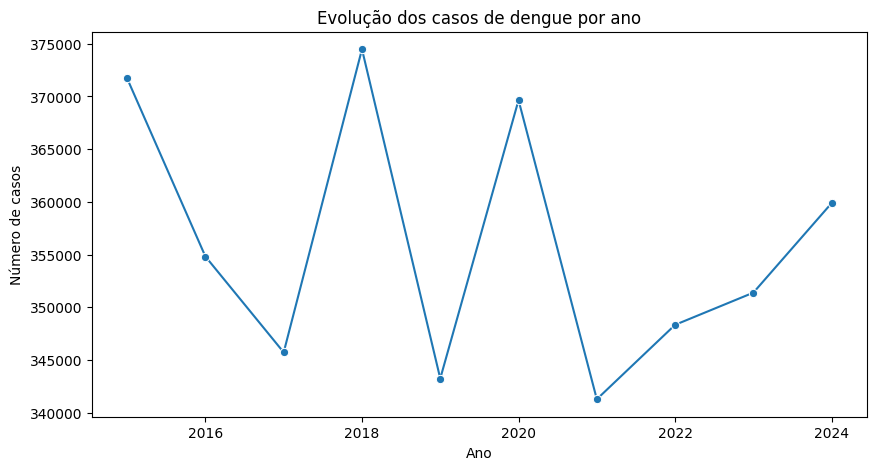

In [18]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=casos_por_ano.index,
    y=casos_por_ano.values,
    marker="o"
)

plt.title("Evolução dos casos de dengue por ano")
plt.xlabel("Ano")
plt.ylabel("Número de casos")
plt.show()

<h4>8.2 Distribuição dos casos por mês</h4>

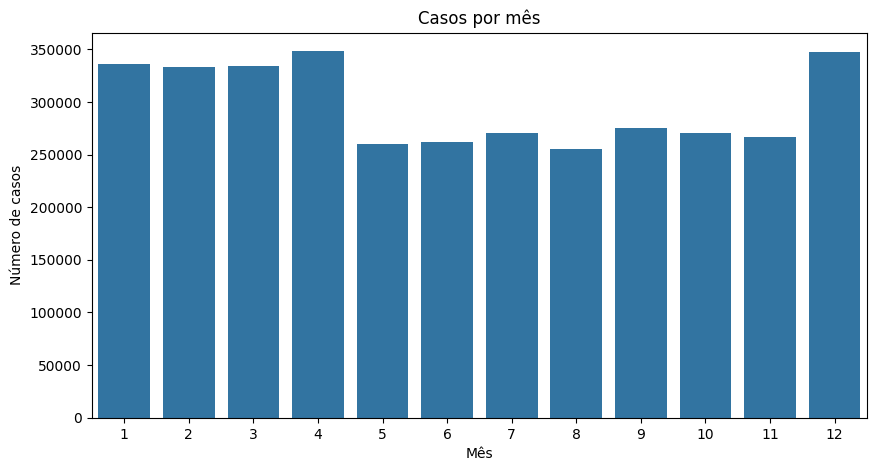

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=casos_por_mes.index,
    y=casos_por_mes.values,
)

plt.title("Casos por mês")
plt.xlabel("Mês")
plt.ylabel("Número de casos")
plt.show()

<h4>8.3 Casos por região</h4>

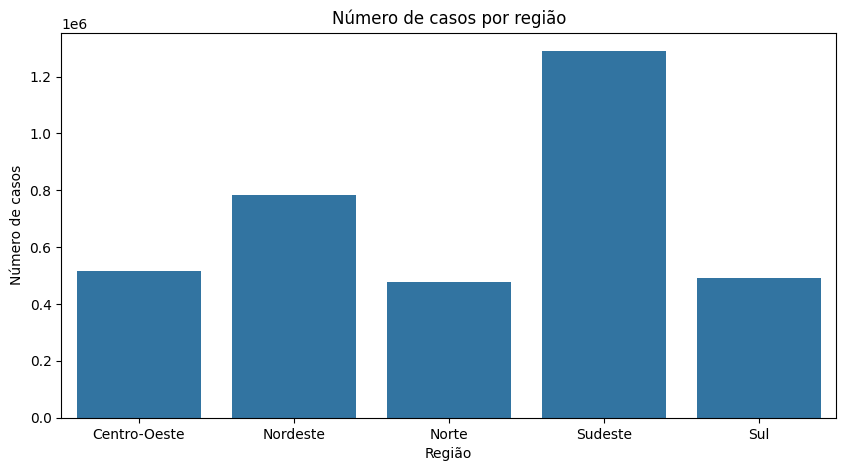

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=casos_por_regiao.index,
    y=casos_por_regiao.values,
)

plt.title("Número de casos por região")
plt.xlabel("Região")
plt.ylabel("Número de casos")
plt.show()

<h4>8.4 Casos por UF</h4>

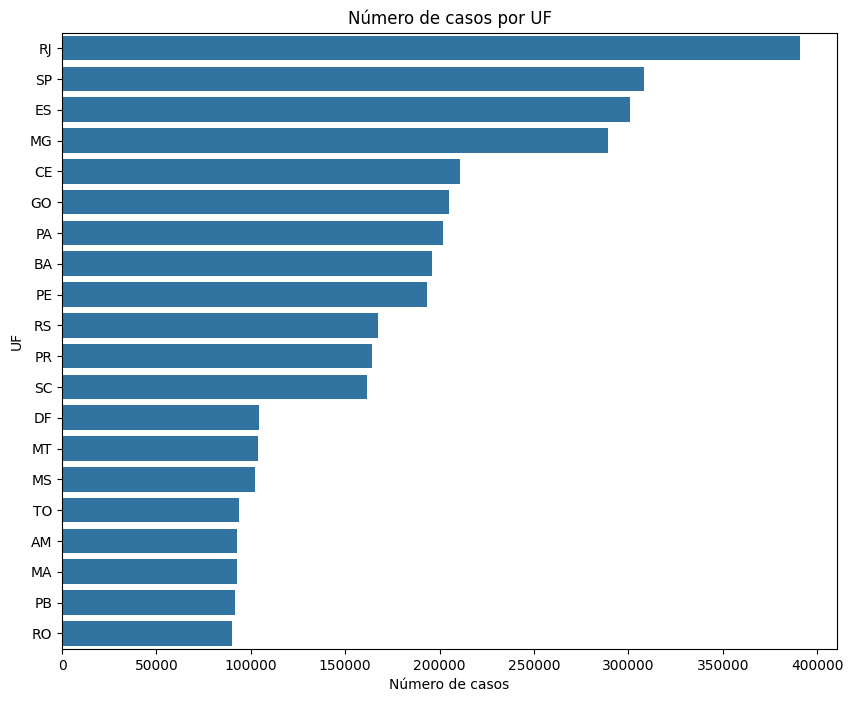

In [21]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x=casos_por_uf_ordenado.values,
    y=casos_por_uf_ordenado.index
)

plt.title("Número de casos por UF")
plt.xlabel("Número de casos")
plt.ylabel("UF")

plt.show()

<h4>8.5 Relação entre chuva e casos de dengue</h4>

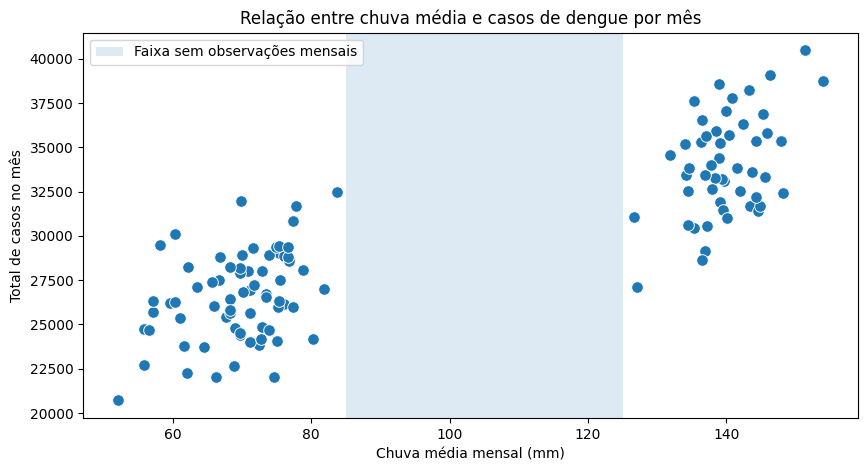

In [22]:
chuva_casos_mes = (
    df.groupby("data")
      .agg(
          chuva_media=("chuva_mm", "mean"),
          casos_totais=("casos_dengue", "sum")
      )
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=chuva_casos_mes,
    x="chuva_media",
    y="casos_totais",
    s=70
)

plt.axvspan(
    85,
    125,
    alpha=0.15,
    label="Faixa sem observações mensais"
)

plt.title("Relação entre chuva média e casos de dengue por mês")
plt.xlabel("Chuva média mensal (mm)")
plt.ylabel("Total de casos no mês")
plt.legend()

plt.show()

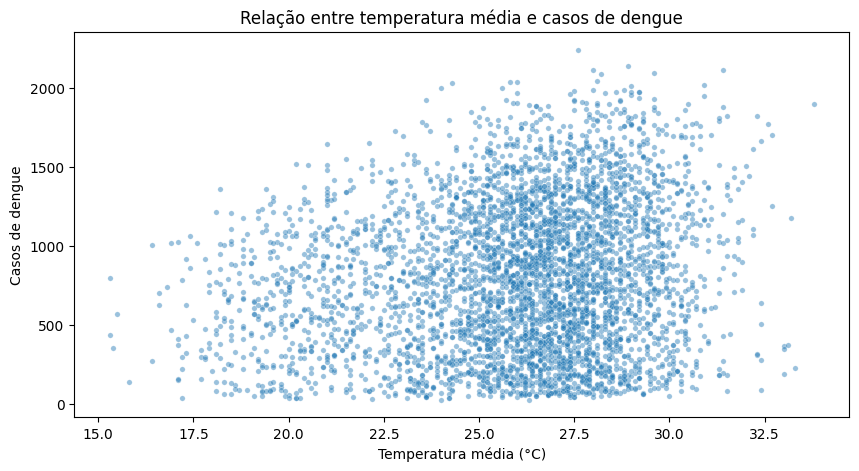

In [37]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="temperatura_media",
    y="casos_dengue",
    alpha=0.45,
    s=15
)

plt.title("Relação entre temperatura média e casos de dengue")
plt.xlabel("Temperatura média (°C)")
plt.ylabel("Casos de dengue")

plt.show()

<h2>9. Interpretação dos Resultados</h2>

<p>A análise mostrou 3.560.562 casos de dengue, 178.670 internações e 5.314 óbitos. A taxa de internação foi de 5,02% e a taxa de mortalidade foi de 0,15%.</p>

<p>O ano de 2018 apresentou a maior quantidade de casos, enquanto 2021 teve o menor número. A região Sudeste concentrou mais casos, e o Rio de Janeiro foi o estado com maior total. Porém, o Nordeste teve a maior incidência média por 100 mil habitantes.</p>

<p>Abril foi o mês com mais casos registrados. A chuva e a temperatura apresentaram relação positiva, mas fraca, com os casos de dengue. Isso indica que outros fatores, como saneamento e prevenção, também influenciam a doença.</p>

<p>Assim, é importante manter ações de combate ao mosquito durante todo o ano, principalmente nas regiões com maior número de casos e incidência.</p>

<h2>10. Conclusão</h2>

<p>Este projeto permitiu analisar os dados simulados de dengue no Brasil entre 2015 e 2024. Foram identificadas diferenças entre anos, regiões e estados, com destaque para a concentração de casos no Sudeste e para a maior incidência média no Nordeste.</p>

<p>Os resultados mostram que a prevenção é importante durante todo o ano, principalmente em locais com maior número de casos. Além disso, fatores como chuva, temperatura, saneamento e eliminação de água parada podem contribuir para o controle da dengue.</p>